In [1]:
import os
print(os.getcwd())

/home/alesau/mllm/mllm-listeners


In [2]:
from models.mllm_wrappers import LLaVA, Qwen, Janus, Qwen3_5, Molmo
from configuration_template import Config

config = Config()
config.input_type = 'simple'
config.task = 'grid'

img_kwargs = {
    "patch_size": config.patch_size*3,
    "patch_padding": config.grid_padding,
    "patch_pad_color": config.grid_pad_color,
}

generate_kwargs = {
        "max_new_tokens": config.max_new_tokens,
        "do_sample": True,
        "temperature": 0.8
    }

model_kwargs = {"cache_dir": config.model_cache_dir, "quant": config.quant}






/home/alesau/miniconda3/envs/mllm/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model_version: Qwen2
model_type: Qwen


In [3]:
Model = Qwen
model = Model(config.model_id, **model_kwargs)
print(f'Model: {model.__class__}')

building Qwen model...


Loading weights: 100%|██████████| 729/729 [00:08<00:00, 84.33it/s] 
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model: <class 'models.mllm_wrappers.Qwen'>


In [4]:
## set randomness
model_mode = 'random'

if model_mode == 'random':
    ## set randomness
    model.model.generation_config.temperature = 0.7
    model.model.generation_config.do_sample = True
    model.model.generation_config.top_p = 0.9
    model.model.generation_config.top_k = 50
else:
    ## set deterministic
    model.model.generation_config.temperature = 0.01
    model.model.generation_config.do_sample = True
    model.model.generation_config.top_p = 0.001
    model.model.generation_config.top_k = 1



In [5]:
# define prompts
TOP_INSTRUCTION = 'In this image you can see three color grids. In the following dialogue, the speaker will describe exactly one of the grids. Please indicate to me whether he refers to the left, middle or right grid.'
BOTTOM_PROMPT = 'Is it the left, middle or right grid?'


##Prompt 1
#SPEAKER_PROMPT_ONE = 'In this image you can see three color grids. Describe the'
#SPEAKER_PROMPT_TWO = 'grid in such a way, that I can identify it among the three grids. You can refer to the color, position and number of objects in the grid, but not to the grid as a whole. Do not refer to the grid as left, middle or right.'


##Prompt 2
SPEAKER_PROMPT_ONE = 'In this image you can see three color grids. Describe the'
SPEAKER_PROMPT_TWO = 'grid in such a way, that I can identify it among the three grids. You can refer to the color, position and number of objects in the grid, but not to the grid as a whole. Do not refer to the grid as left, middle or right. Do not describe the whole grid, if not necessary. You can also just describe one or two objects in the grid, if that is sufficient to identify it. Focus on the most distinctive features of the grid.'

SPEAKER_PROMPT_ONE = 'In this image you can see three colors. Describe the highlighted color in such a way, that I can identify it among the three colors. The color you should describe will be surrounded by a bright green border. Do not refer to the color as left, middle or right. Do not mention the green border. Do not mention any location at all.'
SPEAKER_PROMPT_TWO = ''

SPEAKER_PROMPT_ONE = 'In this image you can see three colors. One color is highlighted with a bright green border. I see the three colors in a different order than you do and i dont see the highlighting. Describe the highlighted color in such a way, that I can identify it among the three colors. Do not refer to the color as left, middle or right. Do not mention the green border. Do not mention any location at all.'


In [6]:
import pandas as pd
import os.path as osp
data_df = pd.read_json(osp.join(config.data_dir, "color_patch_data.json"))
new_responses = []
old_responses = []

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Entry 46956
identifier                                                   8762-f:16
gameid                                                          8762-f
roundNum                                                            16
condition                                                        split
success                                                           True
hls_values                 [[35, 50, 84], [37, 50, 65], [315, 50, 84]]
s_order_t_distr1_distr2                                      [0, 1, 2]
l_order_t_distr1_distr2                                      [0, 1, 2]
conversation                          [[speaker, bright orange, None]]
n_utterances                                                         1
Name: 46956, dtype: object
s_order_t_distr1_distr2: [0, 1, 2]
Generated response: <think>

</think>

The color you are looking for is the warm, earthy orange that appears in the first position from the left. It sits between the muted brown and the vivid pink.



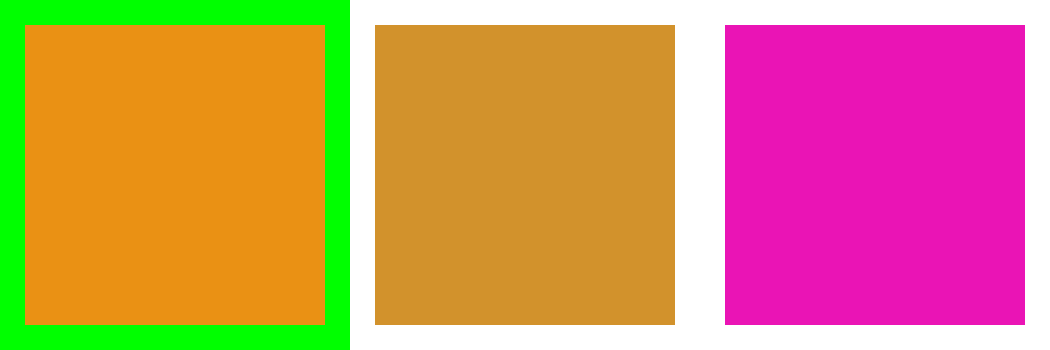

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The color you are looking for is the warm, earthy orange that appears in the first position from the left. It sits between the muted brown and the vivid pink.
 


Entry 21163
identifier                                                         9709-7:24
gameid                                                                9709-7
roundNum                                                                  24
condition                                                              close
success                                                                False
hls_values                     [[178, 50, 13], [165, 50, 27], [177, 50, 23]]
s_order_t_distr1_distr2                                            [1, 0, 2]
l_order_t_distr1_distr2                                            [1, 0, 2]
conversation               [[listener, This one is hard, None], [speaker,...
n_utterances                                              

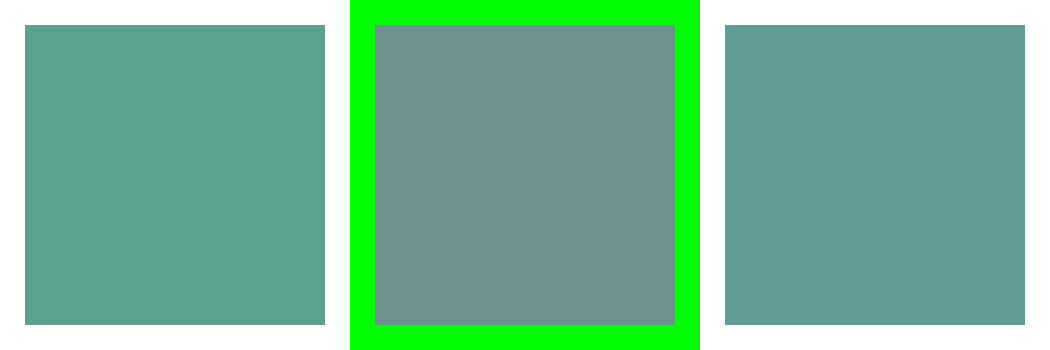

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: middle
Response sentence: <think>

</think>

The color you're looking for is the one that appears largest in the center of the arrangement. It’s positioned between the two smaller, equally sized colors on either side, making it the most prominent visually due to its size.
 


Entry 38273
identifier                                                    8547-9:5
gameid                                                          8547-9
roundNum                                                             5
condition                                                          far
success                                                           True
hls_values                 [[198, 50, 67], [73, 50, 71], [16, 50, 73]]
s_order_t_distr1_distr2                                      [1, 2, 0]
l_order_t_distr1_distr2                                      [1, 2, 0]
conversation                                   [[speaker, blue, None]]
n_utterances                             

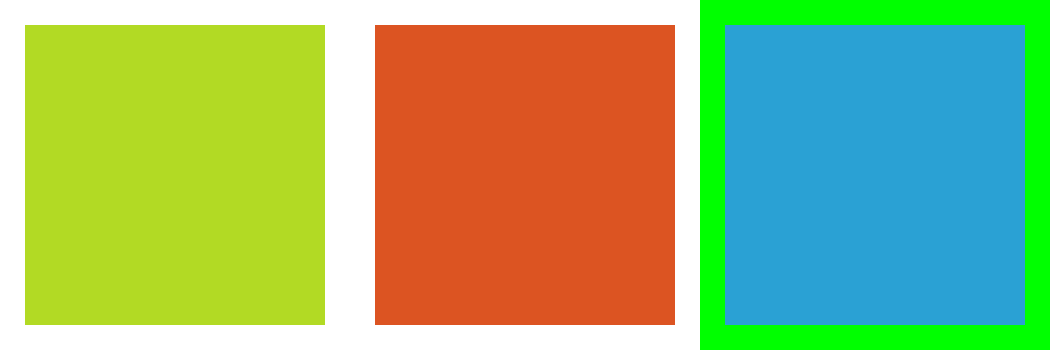

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: right
Response sentence: <think>

</think>

The color that is highlighted by the green border is the one with a medium blue tone. It appears as the third square from the left, standing out due to its distinct hue compared to the others.
 


Entry 31799
identifier                                                  6327-c:30
gameid                                                         6327-c
roundNum                                                           30
condition                                                         far
success                                                          True
hls_values                 [[7, 50, 62], [111, 50, 80], [28, 50, 99]]
s_order_t_distr1_distr2                                     [1, 0, 2]
l_order_t_distr1_distr2                                     [1, 0, 2]
conversation                                   [[speaker, Red, None]]
n_utterances                                                        1
Name: 31799, dty

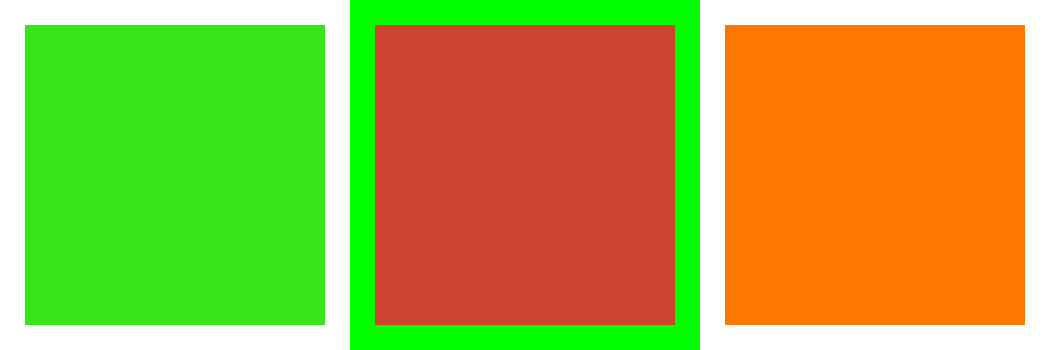

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: middle
Response sentence: <think>

</think>

The color you are looking for is the one located at the center of the image, positioned between the bright green block on one side and the orange block on the other. It is a warm, earthy red tone that appears muted compared to the vivid greens and oranges surrounding it. This central hue is the most prominent in the composition, standing out as the focal point of the arrangement.
 


Entry 45025
identifier                                                   4893-9:33
gameid                                                          4893-9
roundNum                                                            33
condition                                                        split
success                                                           True
hls_values                 [[317, 50, 19], [339, 50, 76], [29, 50, 3]]
s_order_t_distr1_distr2                                      [1, 2, 0]
l_order_t_distr1_distr2     

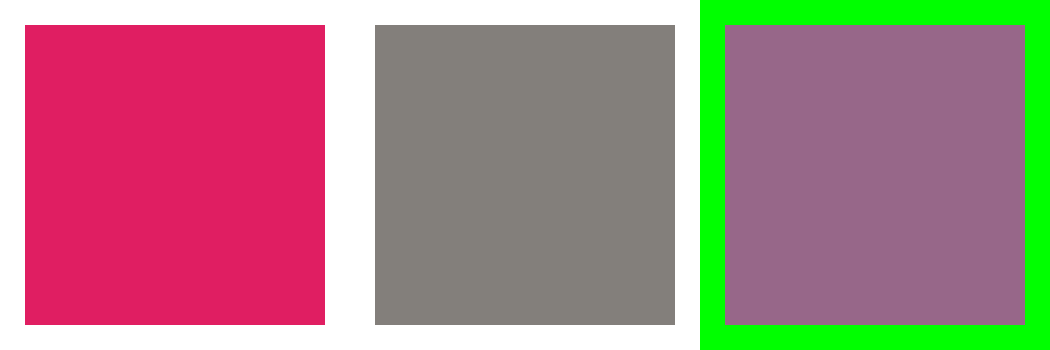

Position described by speaker: right
Response sentence: <think>

</think>

The color that has the bright green border around it is the one that appears as a muted, earthy brownish-purple. It looks like a dull mauve or a brownish lilac, similar to the color of dried figs or the bark of an old tree. Unlike the other two colors, which are solid and vibrant, this one has a more subdued and complex tone that blends warm and cool undertones.
 




In [ ]:
from data_prep.data_utils import build_patch_image_with_target_highlight

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    print(entry)
    img = build_patch_image_with_target_highlight(entry.hls_values, entry.s_order_t_distr1_distr2, **img_kwargs, highlight_target=True)
    position = ""
    print(f"s_order_t_distr1_distr2: {entry.s_order_t_distr1_distr2}")
    entry.target = entry.s_order_t_distr1_distr2.index(0)
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    #full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(SPEAKER_PROMPT_ONE, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Entry 2271


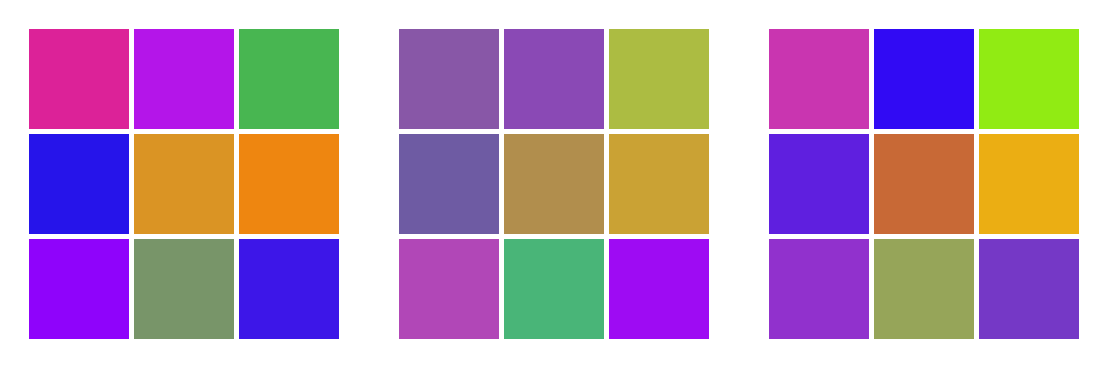

Position described by speaker: left
Response sentence: The left grid has a red square in the top left corner, a green square in the top right corner, a pink square in the bottom left corner, and a purple square in the bottom right corner. The second grid has a blue square in the top left corner, an orange square in the top right corner, a brown square in the bottom left corner, and a red square in the bottom right corner. The third grid has a blue square in the top left corner, a yellow square in the top right corner, a green square in the bottom left corner, and a blue square in the bottom right corner. 


Entry 8698


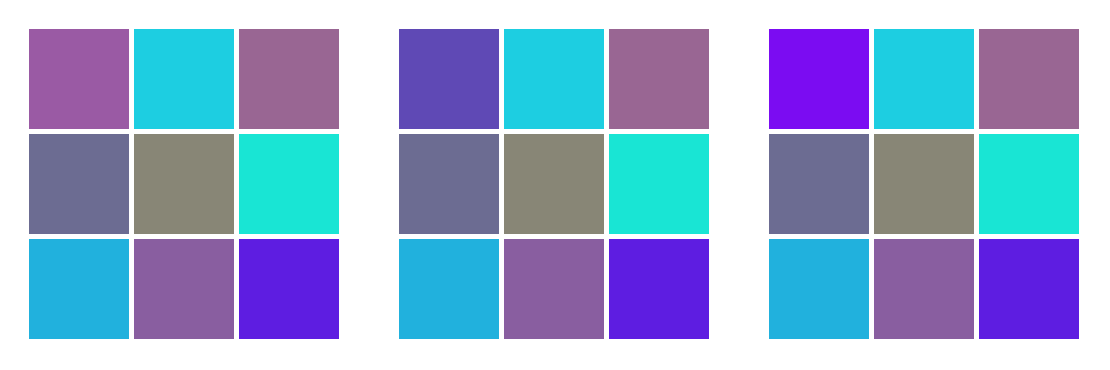

Position described by speaker: left
Response sentence: The left grid features a 4x4 grid of squares, with each square filled with a different color: turquoise, dark purple, light purple, and teal. The colors are arranged in a specific pattern: turquoise at the top left, light purple at the bottom left, dark purple at the top right, and teal at the bottom right. The number of objects in the grid is 16, with 4 squares in each row and column. 


Entry 3753


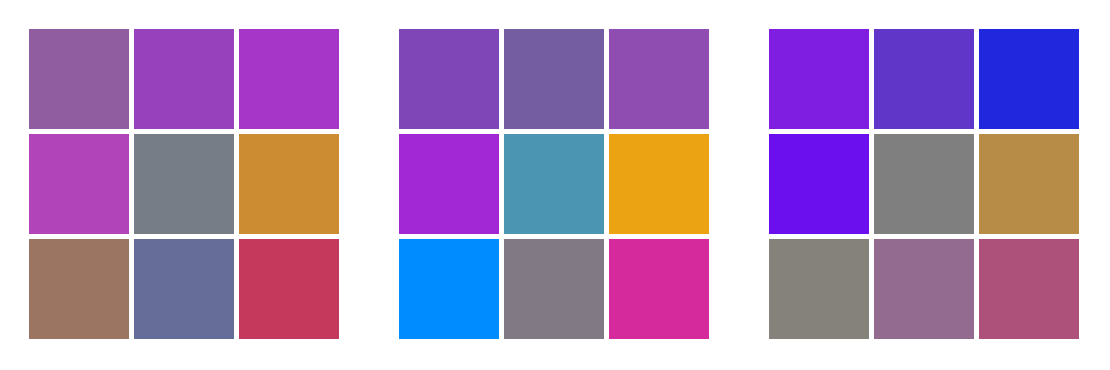

Position described by speaker: right
Response sentence: The right grid has a prominent blue square in the top row, center column, and bottom row. The remaining squares are filled with shades of purple. 


Entry 8665


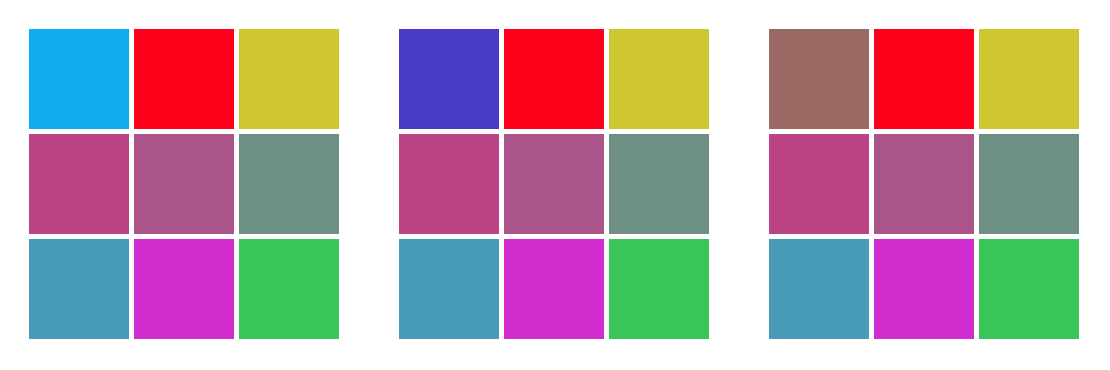

Position described by speaker: left
Response sentence: The left grid features a blue background with a red square in the top row, a yellow square in the middle row, and a purple square in the bottom row. The number of objects in the grid is 12, with 4 blue squares, 4 red squares, 2 yellow squares, and 2 purple squares. 


Entry 4441


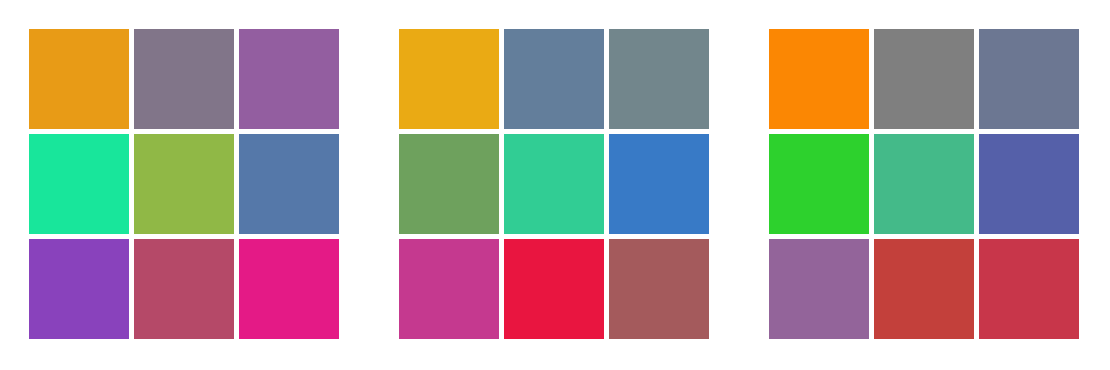

Position described by speaker: left
Response sentence: The left grid contains a combination of colors, specifically a gradient that starts with a lighter color at the top left corner and transitions to a darker color at the bottom left corner. The gradient is composed of shades of orange, purple, and teal. There are 16 squares in total, with each square having a different color. The number of objects in the grid is 16, and the color combination is distinctive. 




In [ ]:
####Qwen2-VL-2B-Instruct


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Qwen3-VL-2B-Instruct
Entry 2271


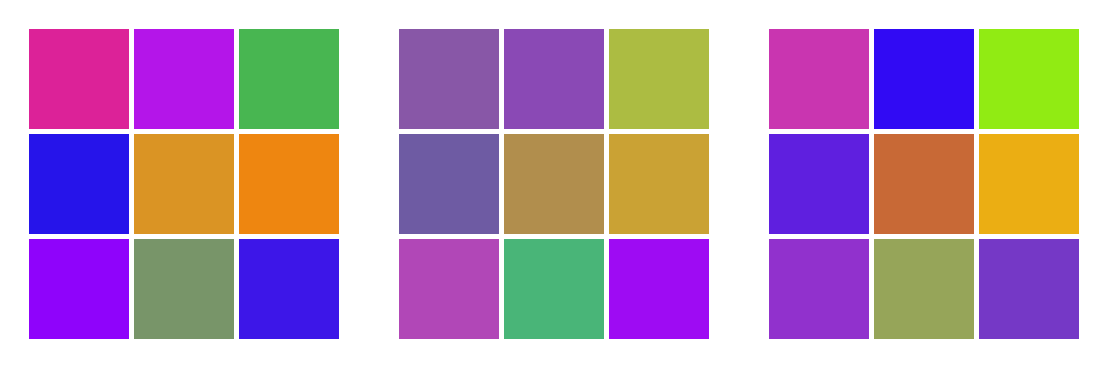

Position described by speaker: left
Response sentence: The leftmost grid has the most distinct visual characteristics. It is the only grid that contains a single object of a color that is not a standard color. This object is a purple square that stands out due to its vibrant hue, which contrasts with the other colors in the grid. The grid is composed of three rows and four columns, with a total of twelve squares. The other grids have different color schemes and patterns. The second grid has a greenish-yellow color, and the third grid has a combination of colors including purple, blue, and yellow. The left grid's distinct feature is the presence of this single, non-standard colored square. 


Entry 8698


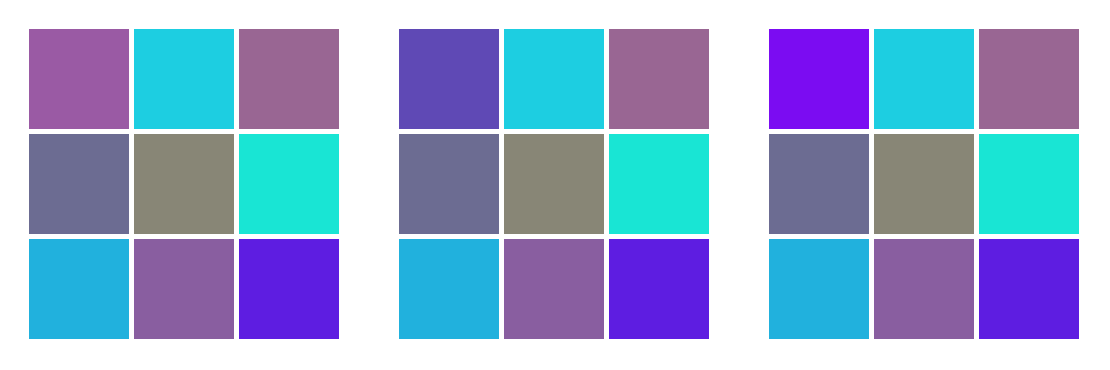

Position described by speaker: left
Response sentence: The left grid is distinguished by its use of two primary colors: a bright teal and a muted purple. It features a layout with five vertical columns and three rows. The most notable feature is the presence of two vertical columns with a single, bright teal color, which stands out due to its brightness against the purple background. The overall pattern is structured with these teal and purple blocks arranged in a grid. 


Entry 3753


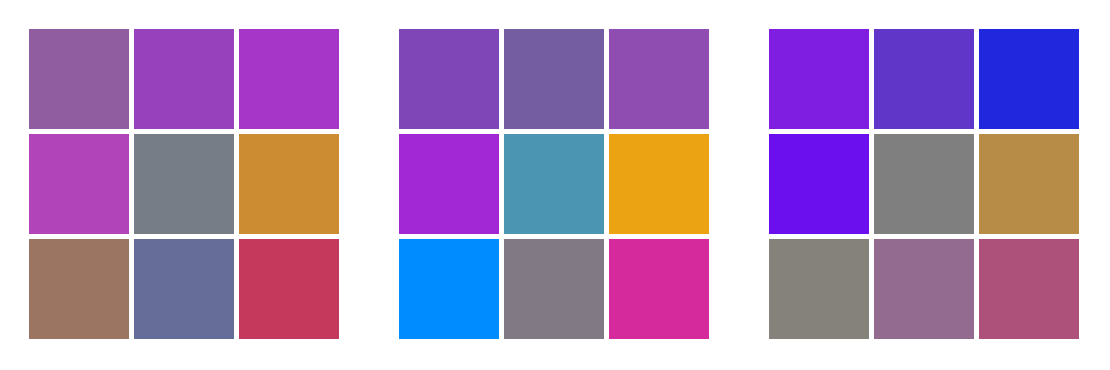

Position described by speaker: right
Response sentence: The rightmost grid is distinguished by its color scheme and the presence of a prominent blue square. Specifically, the grid contains a single blue square, which is the most visually distinct element among the three. This blue square is located in the top row, in the center of the grid, and is positioned directly above the rest of the squares. This unique placement and color make it stand out. Additionally, the grid has a total of 12 squares, which is consistent with the other two grids, but the blue square is the most distinctive feature. The other two grids have a different color scheme, with the middle grid featuring a yellow square, and the left grid featuring a pink square. Therefore, the right grid is identified by the presence of the 


Entry 8665


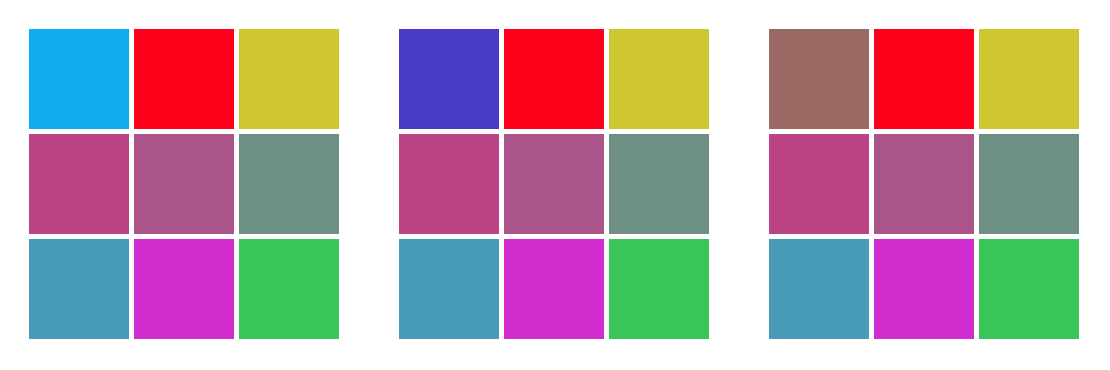

Position described by speaker: left
Response sentence: The leftmost grid is distinguished by its top row containing three bright red squares, which are noticeably more vibrant than the other colors. The grid is also characterized by a blue square in the second row, located at the far left, which stands out due to its distinct color and position. Additionally, the middle of the grid contains a prominent purple square, which is more vivid than the other colors, and is located in the second row, further distinguishing it from the others. These features—specific colors and their positions—help identify the left grid. 


Entry 4441


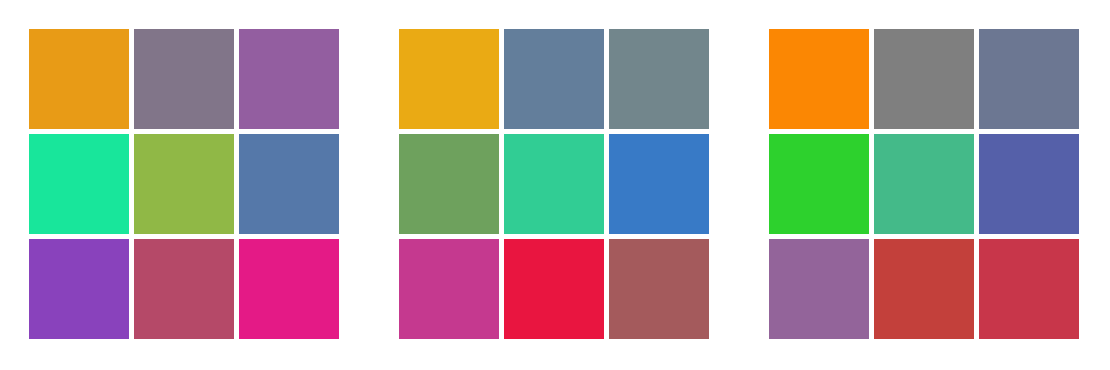

Position described by speaker: left
Response sentence: The leftmost grid is distinguished by its arrangement of colors and the presence of a prominent, centrally located yellowish-orange square. This square is positioned in the upper row and appears to be the most dominant color in the grid. The grid also contains other squares, with one in the lower row being a bright pink, which contrasts with the other colors. The overall composition is distinct, with a notable emphasis on the yellowish-orange square, making it a key identifier for the left grid. 




In [7]:
####Qwen3-VL-2B-Instruct
print("Qwen3-VL-2B-Instruct")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Qwen3.5-0.8B
Entry 2271


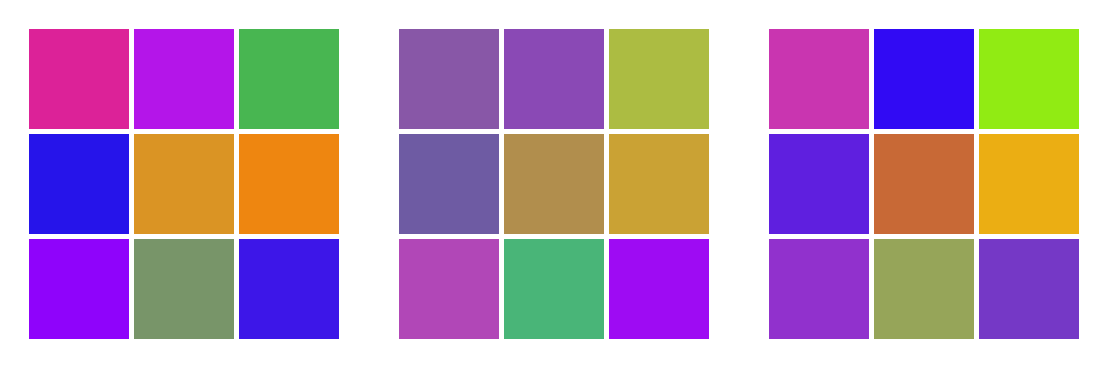

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The leftmost grid is composed of nine squares arranged in a 3x3 layout. Each square contains a distinct color and a specific geometric shape. The top row features a pink square with a star shape, a purple square with a heart shape, and a green square with a lightning bolt shape. The middle row displays an orange square with a circle, a purple square with a heart shape, and a brown square with a circle. The bottom row contains a blue square with a circle, a purple square with a heart shape, and a pink square with a circle. The distinctive features of this grid include the variety of shapes and colors, the even distribution of shapes within each square, and the distinct arrangement of the colors.
 


Entry 8698


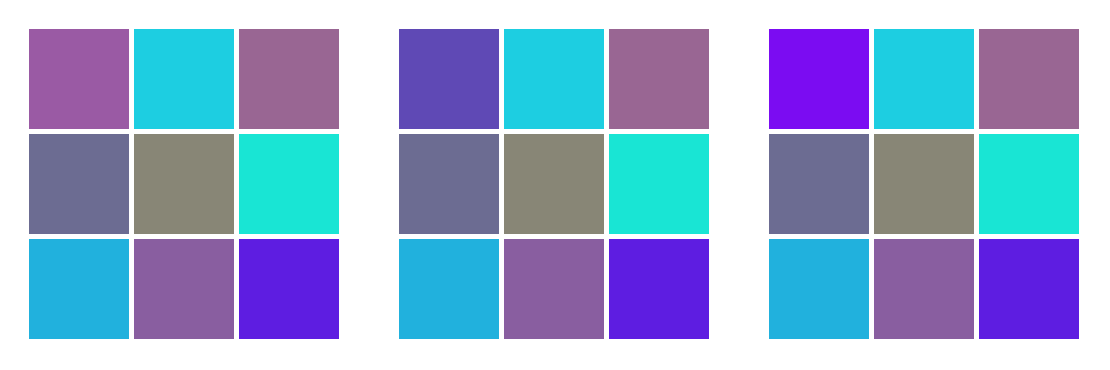

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid consists of four distinct colored squares arranged in a 2x2 structure.

- **Top-left square**: A medium-purple square.
- **Bottom-left square**: A medium-blue square.
- **Top-right square**: A medium-light blue-green square.
- **Bottom-right square**: A medium-dark purple square.

These colors and positions are highly distinct and help distinguish this grid from the others.
 


Entry 3753


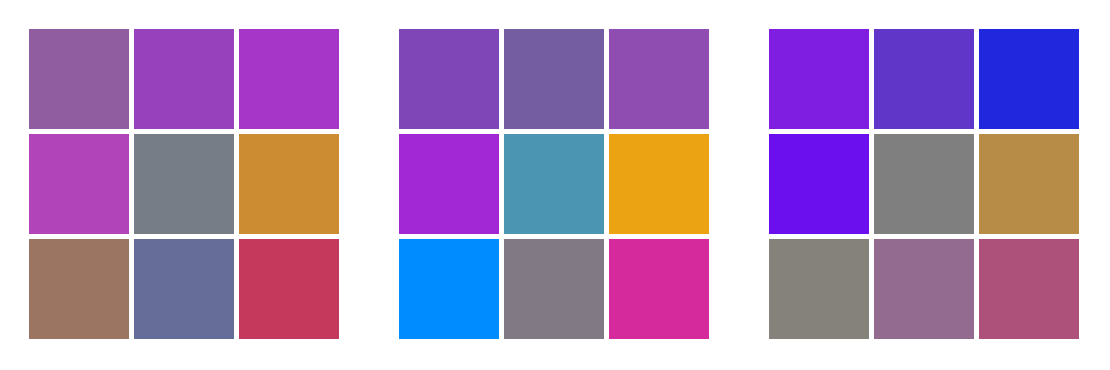

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: right
Response sentence: <think>

</think>

The rightmost grid is a 3x6 grid of colorful squares, each square representing a unique color. The squares are arranged in rows and columns, and each square has a distinct color. The colors are: purple, blue, blue, blue, red, blue, blue, blue, purple, blue, blue, blue, blue, blue, purple, purple, red, red, red, purple, red, red, blue, blue, blue, blue, blue, purple, blue, purple, blue, blue, blue, blue, purple, red, red, blue, blue, blue, blue, blue, purple, blue, purple, blue, blue, blue, blue, blue, purple, red, red, blue 


Entry 8665


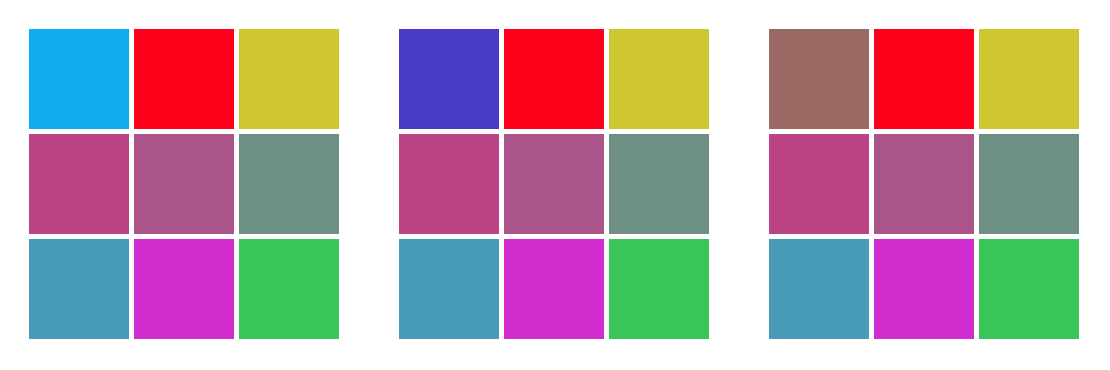

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid consists of three colored blocks arranged in three horizontal rows and three vertical columns, forming a 3x3 grid. The top row contains three squares: the first is a cyan square, the second is a red square, and the third is a gold square. The middle row includes three squares: the first is a maroon square, the second is a green square, and the third is a maroon square. The bottom row features three squares: the first is a teal square, the second is a green square, and the third is a magenta square.
 


Entry 4441


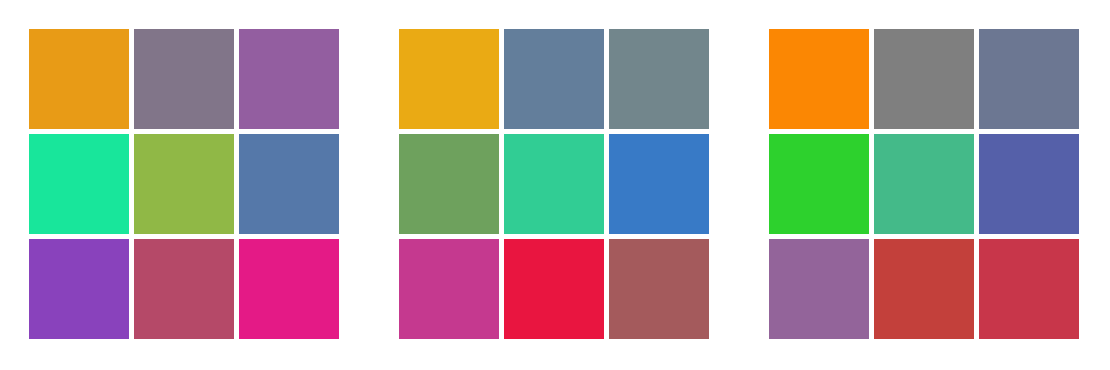

Position described by speaker: left
Response sentence: <think>

</think>

This grid is a 4x4 mosaic of solid-colored squares, each containing a distinct, pure hue. The squares are arranged in a regular 2x2 grid pattern across the image, with each 2x2 block containing four identical squares.

There are 16 squares in total.
The squares are arranged in 2x2 blocks, with each 2x2 block containing four identical squares.

The colors are distinct and solid.
The colors are:
- Orange
- Purple
- Green
- Blue
- Red
- Teal
- Green (appears twice)
- Purple (appears twice)
- Pink (appears twice)
 




In [ ]:
####Qwen3.5-0.8B
print("Qwen3.5-0.8B thinking off")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Qwen3.5-9B thinking off
Entry 2271


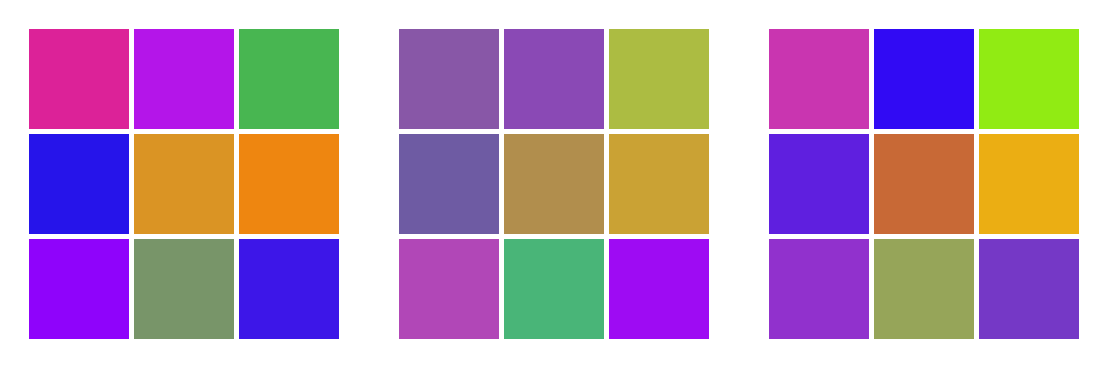

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid contains a bright magenta square in the top-left corner and a vivid orange square in the center-right position. These two colors are unique to this grid compared to the other two.
 


Entry 8698


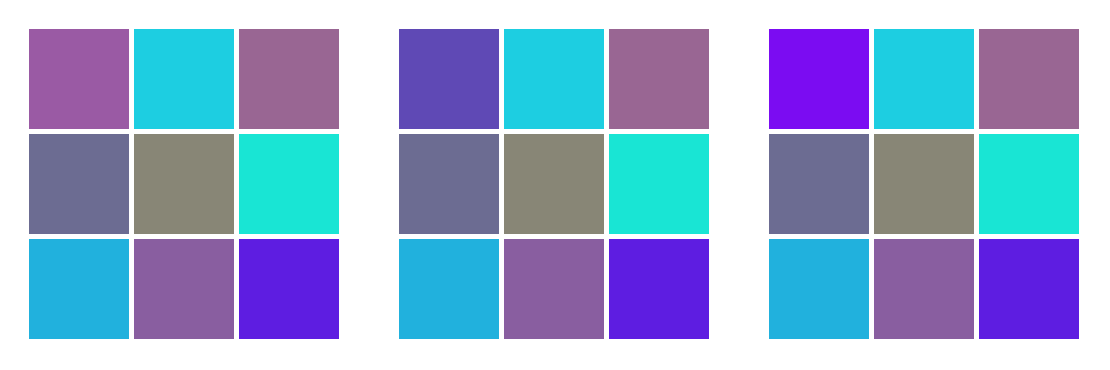

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid contains a bright purple square in the bottom-right corner, which is more vivid and saturated than the purple squares in the other two grids. Additionally, the top-left square in this grid is a muted lavender-purple, distinct from the deeper violet tones found in the other grids.
 


Entry 3753


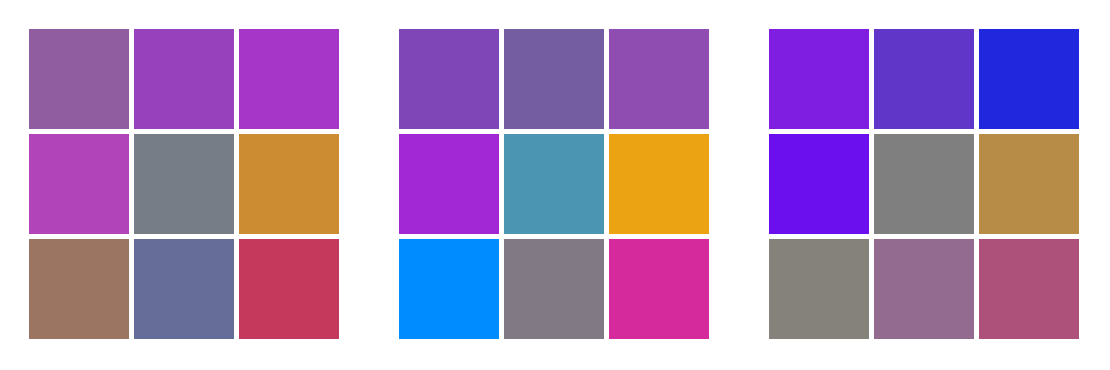

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: right
Response sentence: <think>

</think>

The right grid contains a bright blue square in the top-right corner, which is not present in the other two grids. Additionally, it includes a vibrant purple square in the middle-left position and a deep magenta square in the bottom-right corner — both of which are unique to this grid compared to the others. These distinct, saturated colors make it easily identifiable.
 


Entry 8665


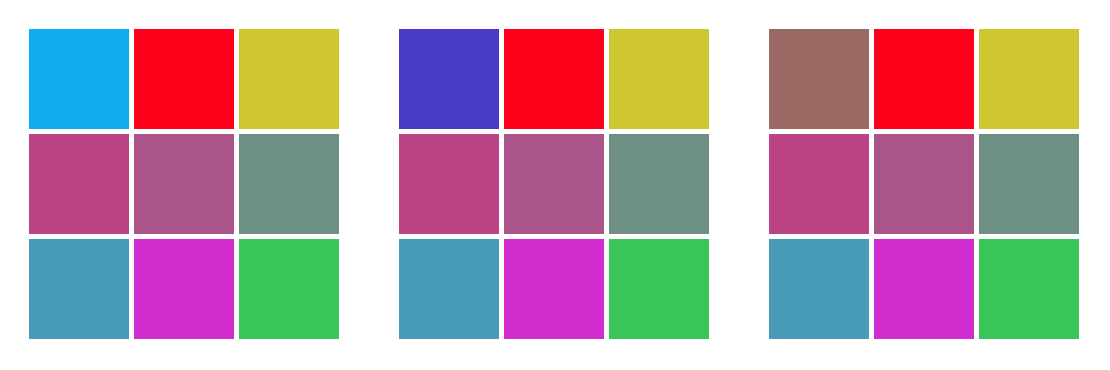

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid is the only one containing a bright cyan square in the top-left corner.
 


Entry 4441


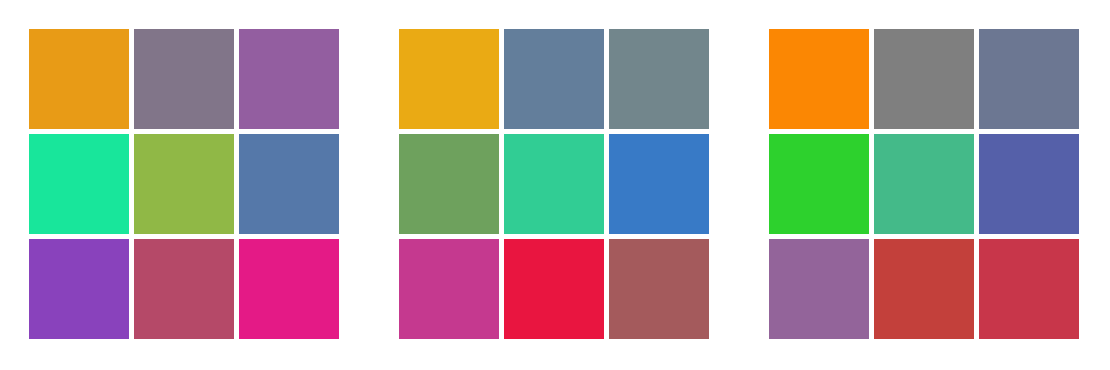

Position described by speaker: left
Response sentence: <think>

</think>

To identify the left grid, focus on these distinctive features:

- The top-left square is a bright, saturated orange (distinctly different from the more muted or yellow-orange tones in the other grids).
- The bottom-left square is a deep purple (not to be confused with the lighter lavender-like purple in the middle grid or the reddish-purple in the right grid).
- The bottom-right square is a vivid magenta/pink — this color does not appear in the other two grids.

These three colors — especially the bright orange at the top-left and the magenta at the bottom-right — are unique to the left grid and will help you pinpoint it.
 




In [7]:
####Qwen3.5-9B
print("Qwen3.5-9B thinking off")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

In [ ]:
####Molmo2-4B
print("Molmo2-4B")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Entry 46956


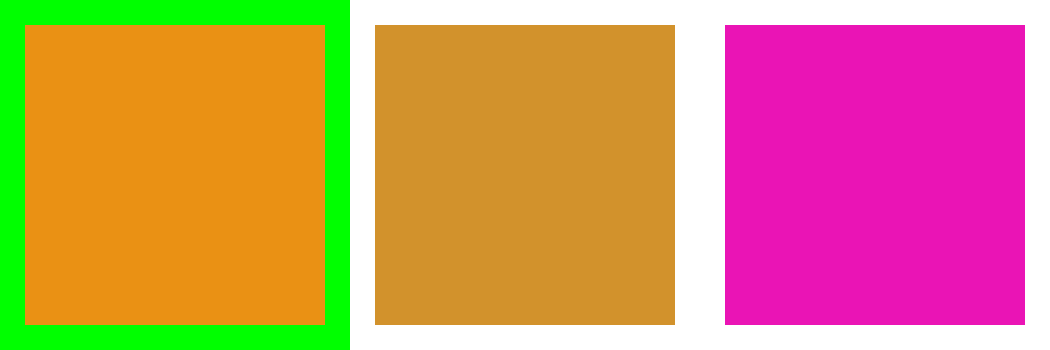

Position described by speaker: left
Response sentence: The highlighted color in the image is a deep orange, positioned on the left side of the three squares. 


Entry 21163


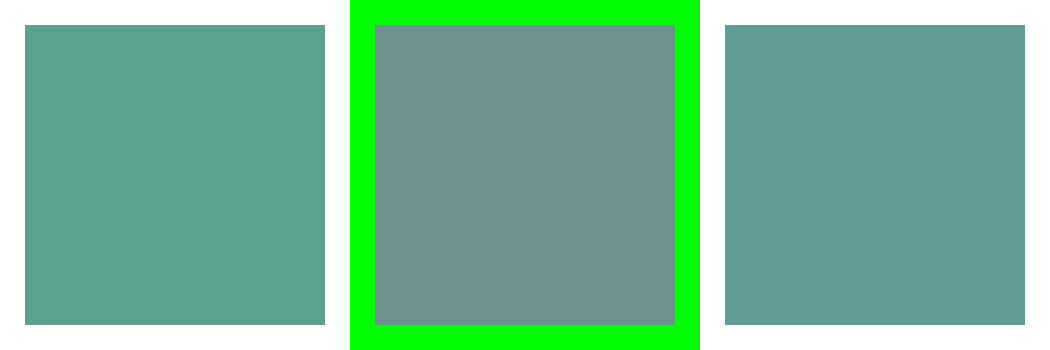

Position described by speaker: middle
Response sentence: The highlighted color, within the context of the three colors presented, is the one that is positioned in the center of the image, surrounded by a bright green border. 


Entry 38273


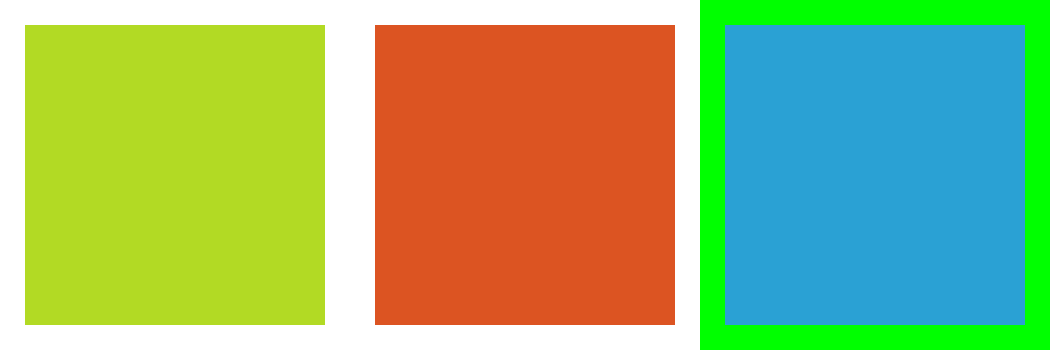

Position described by speaker: right
Response sentence: The highlighted color is lime green. 


Entry 31799


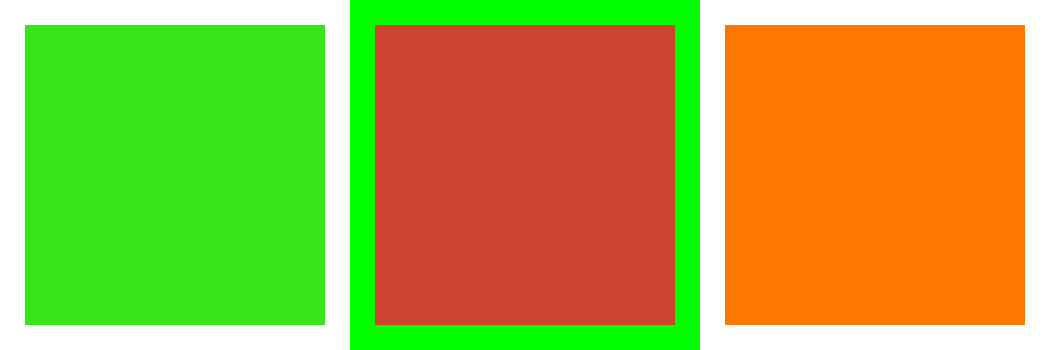

Position described by speaker: middle
Response sentence: The highlighted color is a deep orange. 


Entry 45025


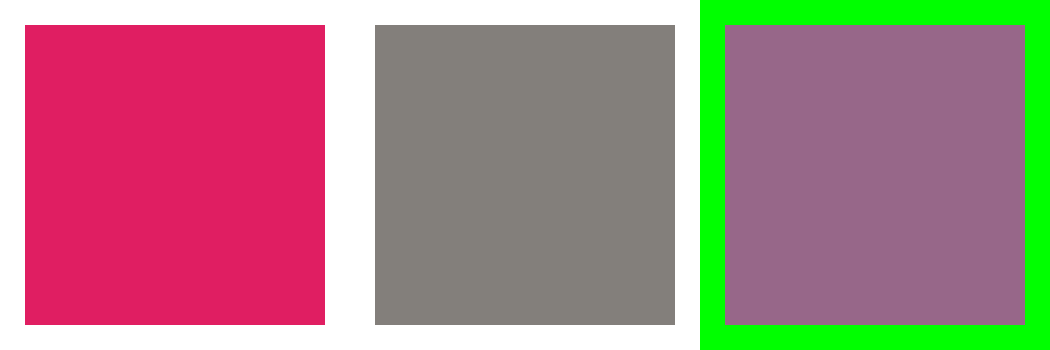

Position described by speaker: right
Response sentence: The highlighted color appears to be a muted shade of pink, similar to the color of a rose. 


Entry 40841


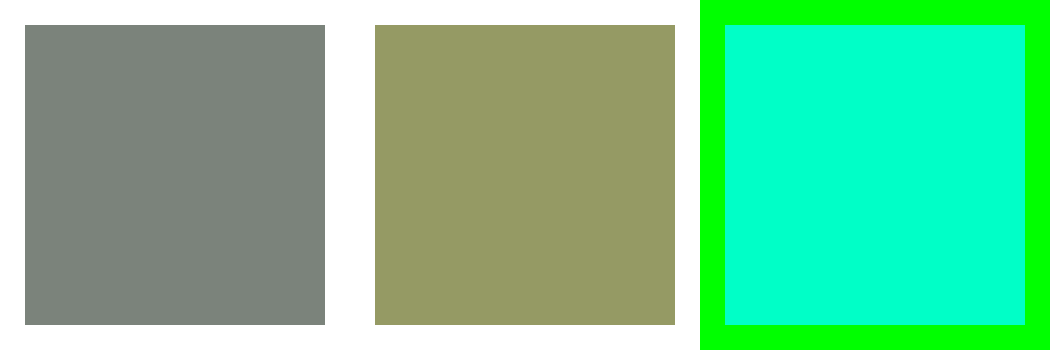

Position described by speaker: right
Response sentence: The highlighted color is a muted beige or light brown. 


Entry 36126


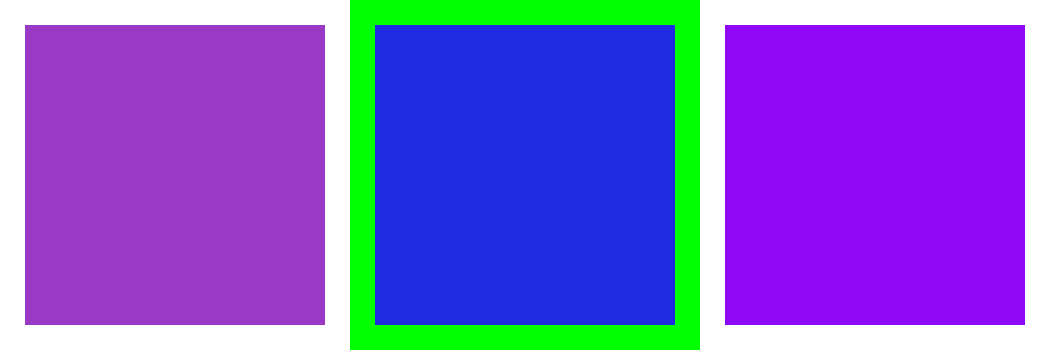

Position described by speaker: middle
Response sentence: The highlighted color is a deep blue. 


Entry 13108


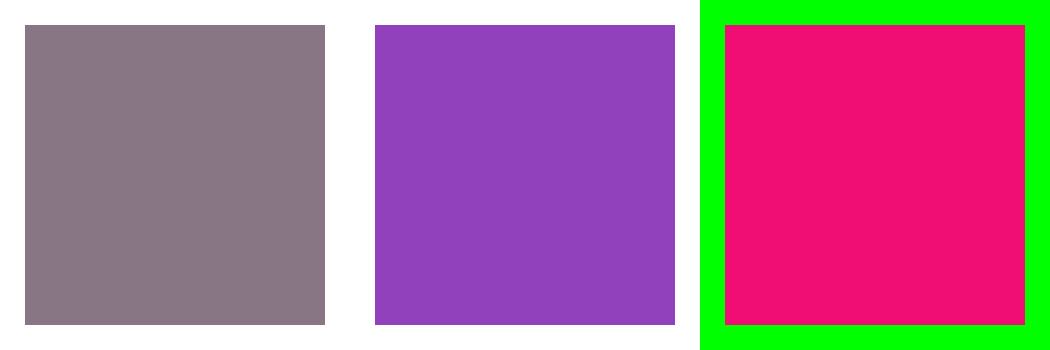

Position described by speaker: right
Response sentence: The highlighted color appears to be a deep, rich purple that is slightly more saturated than a standard purple, almost resembling a deep burgundy. It stands out vividly against the other two colors, which are both shades of gray. 


Entry 44344


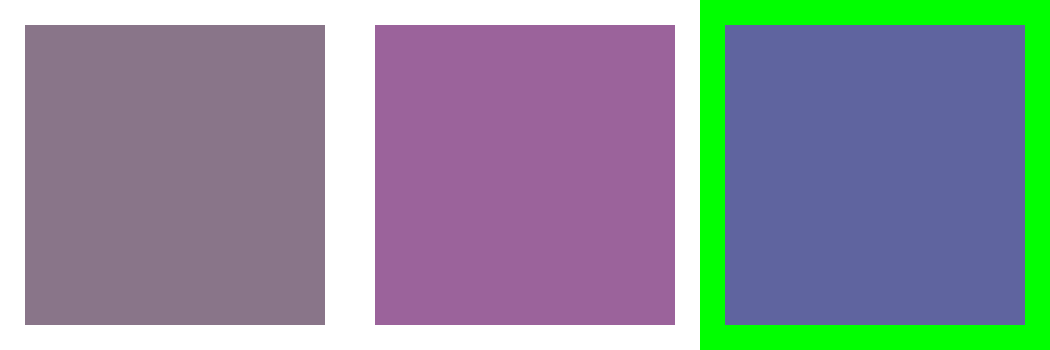

Position described by speaker: right
Response sentence: The highlighted color is a muted purple. 


Entry 5657


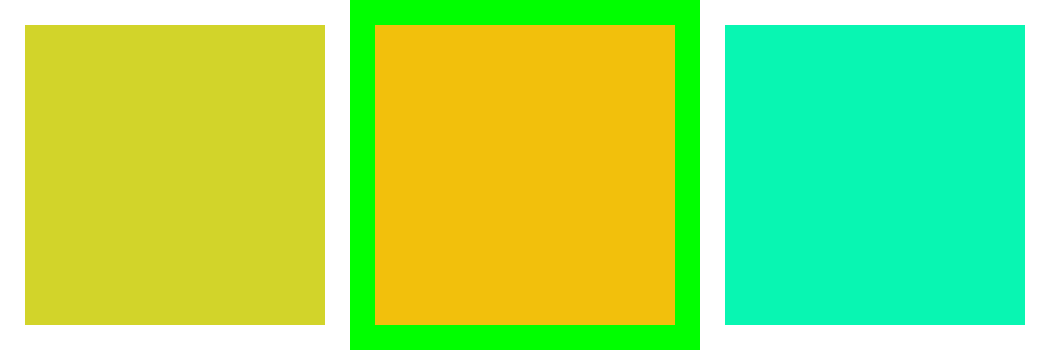

Position described by speaker: middle
Response sentence: The highlighted color is a bright yellow-orange shade, situated in the middle of the three colors displayed. 




In [7]:
from data_prep.data_utils import build_patch_image_with_target_highlight
import base64
from io import BytesIO
from PIL import Image

html_file = open("generated_responses_patches_qwen2_2B.html", "w", encoding="utf-8")

def write_html(text):
    html_file.write(text + "<br>\n")


old_responses = new_responses
new_responses = []

html_file.write(f"<h1>Model: Qwen2-VL-2B-Instruct</h1>")

for i, entry in data_df.sample(n=10, random_state=42).iterrows():
    print(f"Entry {i}")
    write_html(f"<b>Entry {i}</b>")

    img = build_patch_image_with_target_highlight(entry.hls_values, entry.s_order_t_distr1_distr2, **img_kwargs, highlight_target=True)
    position = ""
    entry.target = entry.s_order_t_distr1_distr2.index(0)
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    #full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(SPEAKER_PROMPT_ONE, img, **generate_kwargs)
    display(img)

    buffer = BytesIO()
    img.save(buffer, format="PNG")
    img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

    write_html(f'<img src="data:image/png;base64,{img_base64}">')

    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")

    write_html(f"Position described by speaker: {position}")
    write_html(f"Response sentence: {response_sentence}")
    write_html("<hr>")

    new_responses.append(response_sentence)

html_file.close()

In [12]:


for i in range(5):
    if old_responses[i] != new_responses[i]:
        print(f"Response changed for entry {i}")
    else:
        print(f"Response did not change for entry {i}")

Response changed for entry 0
Response changed for entry 1
Response changed for entry 2
Response changed for entry 3
Response changed for entry 4


In [7]:
print(model.model.generation_config)
model.model.generation_config.temperature = 0.7

GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "pad_token_id": 151643,
  "repetition_penalty": 1.0,
  "temperature": 0.7,
  "top_k": 1,
  "top_p": 0.001
}



In [ ]:


response_sentence = model.generate(
            full_prompt, img, prune_output_to_response=True, **generate_kwargs)